# Assignment 7: Graph Theory

Solutions to the following exercises are to be handed in, either typed or handwritten. Write neatly and concisely, so the solutions are easy to read. You are allowed (even encouraged) to work in groups, but solutions have to be written and handed in individually. If you worked in groups, please state on your answer sheet who you worked with. 

1. (MIT 12.23) Let $G$ be the graph below. Carefully explain why $\chi(G) = 4$. 
    
    ![alt text](graph.png)

2. (MIT 12.29) Let $G$ be a graph whose vertex degrees are all at most $k$. Prove by induction on the number of vertices that if every connected component of $G$ has a vertex of degree strictly smaller than $k$, then $G$ is $k$-colorable. 





### Programming Exercise

This assignment is about **random graphs**, which is a graph picked at random from a distribution. We will in particular consider the **Erdős–Rényi** random graph ([here](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model) is the Wikipedia page), which is a graph where for each pair of vertices, we flip a coin which is heads with probability $p$ and tails with probability $1-p$, and add the edge if the coin turns up heads. We denote a random graph sampled in this way by $G(n, p)$.

**Task 1:** Write a function `erdosrenyi(n, p)` that when called generates a graph $G(n,p)$ in adjacency list form, and then plots it using the `plot_graph` function below. Try it out on some small graphs with around 20 vertices. The adjacency list representation should be a [dictionary](https://www.geeksforgeeks.org/python/python-dictionary/), where each key is a vertex and each value is the list of vertices adjacent to it. The `random` package is useful here. Remember to only flip a coin for each vertex pair once!

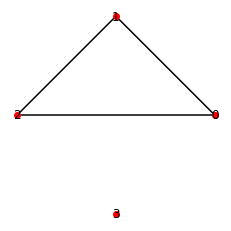

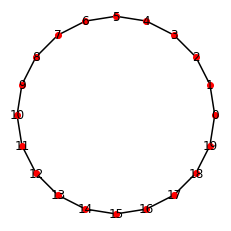

In [2]:
import random
import matplotlib.pyplot as plt
import math


def erdosrenyi(n, p):
    return



def plot_graph(adj):
    
    vertices = list(adj.keys())
    n = len(vertices)

    # Compute circular layout
    angles = {v: 2 * math.pi * i / n for i, v in enumerate(vertices)}
    pos = {
        v: (math.cos(angles[v]), math.sin(angles[v]))
        for v in vertices
    }

    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw edges
    for v in vertices:
        x1, y1 = pos[v]
        for u in adj[v]:
            x2, y2 = pos[u]
            # Draw each edge once
            if v < u:
                ax.plot([x1, x2], [y1, y2], color='black')

    # Draw vertices
    xs = [pos[v][0] for v in vertices]
    ys = [pos[v][1] for v in vertices]
    ax.scatter(xs, ys, color='red', zorder=3)

    # Label vertices
    for v in vertices:
        x, y = pos[v]
        ax.text(x, y, str(v), fontsize=12, ha='center', va='center')

    plt.show()


# Example usage:
if __name__ == "__main__":
    graph = {
        0: [1, 2],
        1: [0, 2],
        2: [0, 1],
        3: []
    }
    plot_graph(graph)


C20 = {
    i: [(i - 1) % 20, (i + 1) % 20]
    for i in range(20)
}
plot_graph(C20)


The random graph $G(n, p)$ has very interesting properties. In particular, it exhibits what are known as *phase transitions*. You are already familiar with this phenomenon from everyday life: water is liquid until it is heated to precisely 100 degrees Celsius, and then it evaporates into steam. 

 In a similar fashion, the properties of $G(n, p)$ change rapidly for some special values of $p$. Whether or not $G(n, p)$ is connected is one such property: there exists a value $p_c$ such that for all $p \leq p_c$, the probability that $G(n, p)$ is connected goes to zero as $n\to \infty$, and the probability that $G(n, p)$ is connected goes to $1$ as $n\to \infty$ if $p \geq (1+\varepsilon)p_c$, for any $\varepsilon>0$. The value $p_c$ is called the *threshold probability* for connectivity. It turns out that $p_c = \ln{n}/n$, and in Tasks 2 and 3 you will see this in practice using simulations. 

**Task 2:** Write a function `is_connected(G)` that returns `True` if the input graph is connected and `False` otherwise. Hint: This is probably easiest using Depth First Search (DFS) as a helper function. DFS has a very simple recursive implementation; see, for instance, the [Wikipedia page](https://en.wikipedia.org/wiki/Depth-first_search#Pseudocode).

In [ ]:
def dfs(graph, start, visited=None):
    return


# To avoid recursion error
def dfs_iterative(graph, start):
    return


def is_connected(graph):
    return


**Task 3:** The threshold probability for connectivity for $G(n, p)$ is $p_c = \ln{n}/n$. Use your algorithm from Task 2 and your graph generator from Task 1 to see this experimentally by following the procedure below for $a \in \{0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3\}$:
1. Set $p = a\ln{n}/n$. 
2. Generate $200$ random graphs $G(n, p)$ for $n=2000$ and $p$ as above.
3. Check the proportion of these $200$ graphs that are connected, using your function `is_connected(G)`. 

Compare your results for the different values of $a$. 

**Note:** If you encounter problems with recursion depth, lower the number of vertices $n$. The effect is more dramatic for larger $n$, but are clearly visible also with $n=1000$, for instance. If you want to see it more clearly, there is also a very simple iterative implementation of DFS that avoids problems with recursion depth.  


In [ ]:
import math


def test_connectivity(n, a, trials):
    return

0.015
0.135
0.375
0.655
0.805
0.94
